# tACS Bandit: Main Analyses

**Study:** Examining the effects of theta-tACS over left DLPFC on reward-based learning across the adult lifespan

**Design:** Within-subject crossover (active vs. sham theta-tACS, 6 Hz)

This notebook orchestrates all pre-registered and exploratory analyses by calling modular functions. Individual modules contain the implementation details.

---
## 0. Setup & Imports

In [3]:
# Standard
import numpy as np
import pandas as pd
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Visualization
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.templates.default = 'plotly_white'

# Project modules
from config import *
from data_loading import load_all_subjects, summarize_loading
from exclusions import apply_all_exclusions
from sample_descriptives import run_sample_descriptives
from blinding_analysis import run_blinding_analysis
from wsls import run_wsls_analysis
from reversal_analysis import run_reversal_analysis
from rescorla_wagner import run_rw_analysis
from ddm import run_ddm_analysis
from eeg_theta import run_theta_analysis
from cognitive_merge import run_cognitive_merge
from hypothesis_tests import run_hypothesis_tests
from order_effects import run_order_effects_analysis
from correlations import run_correlation_analysis

print(f'Study: {len(SUBJECT_INFO)} participants in SUBJECT_INFO')
print(f'Data directory: {DATA_DIR}')

Study: 32 participants in SUBJECT_INFO
Data directory: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/data/bandit


---
## 1. Data Loading & Preprocessing

In [5]:
# Load all behavioral data
data = load_all_subjects()
summarize_loading(data)

Loading sub-10369...
  Run 1: 67 trials, 4 missed
  Run 2: 68 trials, 2 missed
  Run 3: 74 trials, 0 missed
  Run 4: 77 trials, 0 missed
  Run 5: 79 trials, 0 missed
  Run 6: 76 trials, 1 missed
  Run 7: 76 trials, 0 missed
  Run 8: 77 trials, 0 missed
Loading sub-10418...
  Run 1: 73 trials, 0 missed
  Run 2: 71 trials, 0 missed
  Run 3: 73 trials, 0 missed
  Run 4: 73 trials, 0 missed
  Run 5: 74 trials, 0 missed
  Run 6: 73 trials, 0 missed
  Run 7: 70 trials, 1 missed
  Run 8: 69 trials, 0 missed
Loading sub-10541...
  Run 1: 70 trials, 2 missed
  Run 2: 69 trials, 1 missed
  Run 3: 70 trials, 4 missed
  Run 4: 71 trials, 5 missed
  Run 5: 72 trials, 0 missed
  Run 6: 72 trials, 2 missed
  Run 7: 73 trials, 1 missed
  Run 8: 71 trials, 2 missed
Loading sub-10559...
  Run 1: 72 trials, 2 missed
  Run 2: 72 trials, 4 missed
  Run 3: 76 trials, 1 missed
  Run 4: 77 trials, 0 missed
  Run 5: 77 trials, 0 missed
  Run 6: 75 trials, 1 missed
  Run 7: 74 trials, 2 missed
  Run 8: 73 trial

,subject_id,n_runs,n_trials,n_missed,pct_missed,counterbalance,conditions
0,10369,8,594,7,1.178451,B,"[active, baseline, post, sham]"
1,10418,8,576,1,0.173611,B,"[active, baseline, post, sham]"
2,10541,8,568,17,2.992958,B,"[active, baseline, post, sham]"
3,10559,8,596,13,2.181208,A,"[active, baseline, post, sham]"
4,10589,8,597,3,0.502513,A,"[active, baseline, post, sham]"
5,10606,8,598,2,0.334448,A,"[active, baseline, post, sham]"
6,10608,8,586,3,0.511945,A,"[active, baseline, post, sham]"
7,10636,8,611,3,0.490998,B,"[active, baseline, post, sham]"
8,10638,8,578,10,1.730104,B,"[active, baseline, post, sham]"
9,10641,8,593,3,0.505902,B,"[active, baseline, post, sham]"


In [6]:
# Apply exclusion criteria
exclusion_results = apply_all_exclusions(data)

# Extract filtered datasets
data_h1 = exclusion_results['data_h1']       # H1 analyses: sham only, behavioral exclusions
data_h2 = exclusion_results['data_h2']       # H2 analyses: active vs sham, all exclusions
data_clean = exclusion_results['data_clean'] # All clean trials
run_exclusions = exclusion_results['run_exclusions']
h2_eligible = exclusion_results['h2_eligible']

print(f'\nH1-eligible subjects: {data_h1["subject_id"].nunique()}')
print(f'H2-eligible subjects: {len(h2_eligible)}')

Computing Pre-Registered Exclusion Criteria

Behavioral Exclusion Summary (Run-Level):
--------------------------------------------------
  ⚠ >20% missed trials: 1/248 runs (0%)
  ⚠ Side bias (>95%): 3/248 runs (1%)
  ⚠ Stimulus bias (>95%): 6/248 runs (2%)
  ⚠ Rapid responding (<200ms): 1/248 runs (0%)
  ⚠ Feedback invariance (10+ losses): 2/248 runs (1%)

Stimulation Administration Exclusions: 3 runs
  sub-10998 Run 6: Experimenter error: sham protocol loaded instead of active
  sub-11773 Run 6: Experimenter error: sham protocol loaded instead of active
  sub-11773 Run 7: Experimenter error: sham protocol loaded instead of active

Combined Exclusion Summary

Total subjects: 31
Total runs: 248
Runs excluded (behavioral): 12
Runs excluded (stim admin): 3
Unique runs excluded for H2: 14

H1 sample (sham, behavioral exclusions):
  31 subjects, 61 clean sham runs, 4509 trials

H2 sample (active vs. sham, all exclusions + min-run threshold):
  29 subjects eligible for paired comparisons, 8

---
## 2. Sample Descriptives & Demographics

Sample Descriptives

N = 32
Age: M = 45.5, SD = 19.8, range = 23–75

Gender:
  Female: 17 (53%)
  Male: 15 (47%)

Race:
  White: 24 (75%)
  Black or African American: 4 (12%)
  Asian: 3 (9%)
  Two or more races, or race not described (other): 1 (3%)

Ethnicity:
  Not Hispanic or Latino: 28 (88%)
  Hispanic or Latino: 3 (9%)
  Ethnicity not described (Other): 1 (3%)



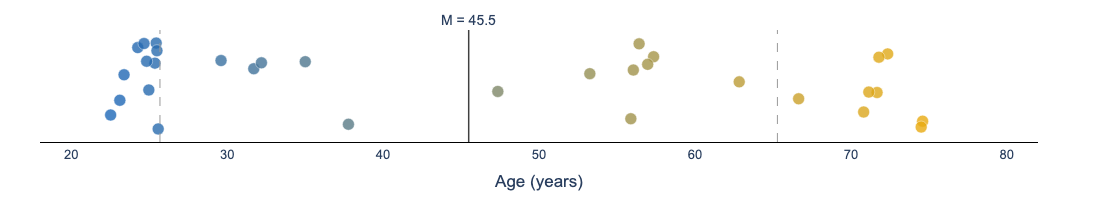


Estimated vs Actual Cap Size Comparison

Subjects with ICV data: 32
Subjects with both estimated and actual: 25
  Matches (same size): 15
  Off by 1 size: 9
  Off by 2 sizes: 1

Mismatch direction:
  Actual smaller than estimated: 9
  Actual larger than estimated: 1

 Subject      ICV      Estimated       Actual       Status
------------------------------------------------------------
   10369   1534.5          Large        Large      ✓ Match
   10418   1329.0              —       Medium   Incomplete
   10541   1614.6    Extra Large        Large    ✗ +1 size
   10559   1443.6          Large        Large      ✓ Match
   10589   1494.2          Large            —   Incomplete
   10606   1489.6          Large        Large      ✓ Match
   10608   1197.5          Small        Small      ✓ Match
   10636   1313.4              —        Small   Incomplete
   10638   1235.7          Small        Small      ✓ Match
   10641   1313.5          Small        Small      ✓ Match
   10649   1395.5    

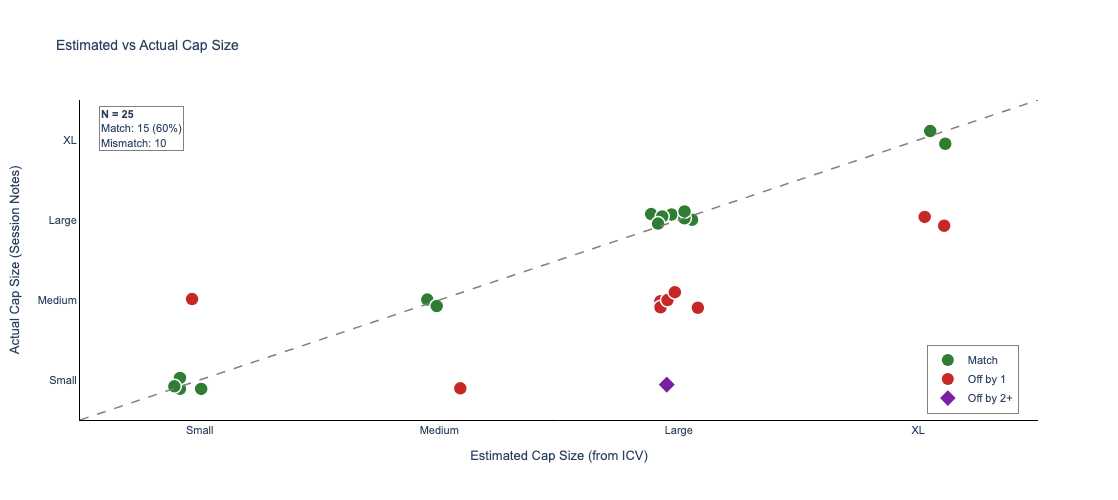

In [8]:
# Demographics and cap size analysis
desc_results = run_sample_descriptives()

---
## 3. Blinding Integrity

Blinding Integrity Analysis

Data: 117 run-level observations from 31 participants

--- Contingency Table ---
                 Participant Guess
Actual Condition   Active    Sham    Total
---------------------------------------------
     Active            43       16       59
      Sham             33       25       58
---------------------------------------------
     Total             76       41      117

--- Signal Detection Metrics ---
  Hits (say Active | Active):            43 / 59 = 72.9%
  Misses (say Sham | Active):            16 / 59 = 27.1%
  False Alarms (say Active | Sham):      33 / 58 = 56.9%
  Correct Rejections (say Sham | Sham):  25 / 58 = 43.1%

  d' (sensitivity):  +0.43  (near zero — no discrimination)
  c (criterion):     -0.38  (bias toward "Active")

  Overall accuracy: 58.1% (68/117)
  Binomial vs 50%: p = 0.096
  χ² = 2.62, p = 0.106

--- By Counterbalance Order ---
Order    N_runs        Hits          FA       d'      Acc
-----------------------------------

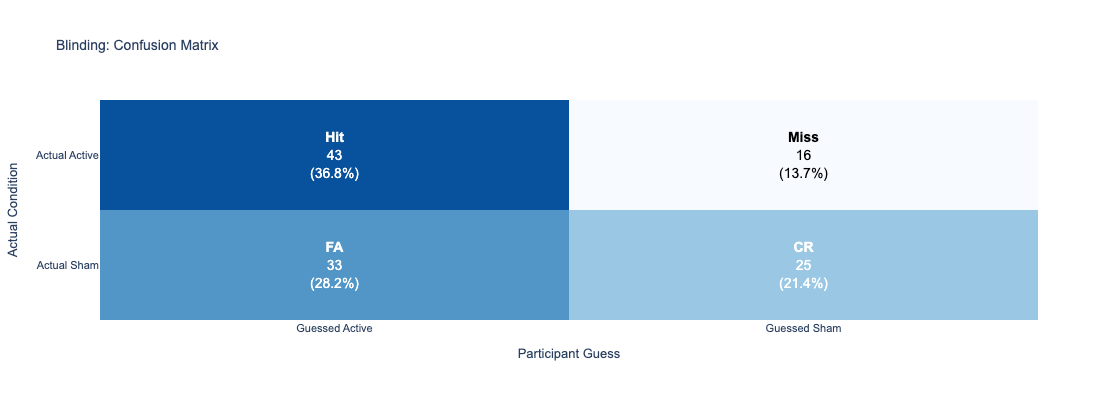

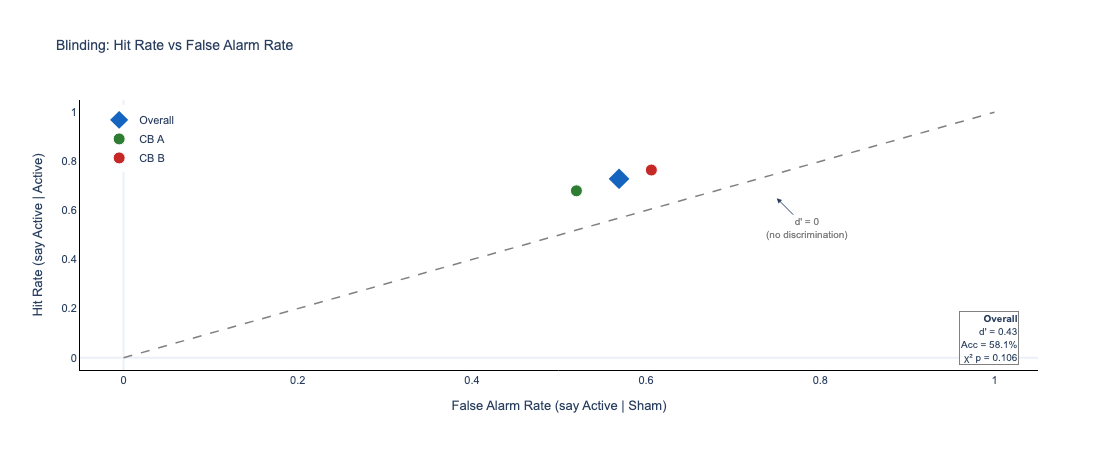


✓ Blinding appears intact


In [10]:
# Signal detection analysis of blinding
blinding_results = run_blinding_analysis(data_clean)

if blinding_results['blinding_intact']:
    print('\n✓ Blinding appears intact')
else:
    print('\n⚠ Blinding may be compromised — interpret with caution')

---
## 4. Win-Stay / Lose-Shift Analysis

H1 WSLS (sham, clean runs):
subject_id  p_stay_win  p_shift_lose  n_win_trials  n_lose_trials  n_total_trials
     10369    0.591549      0.507692            71             65             136
     10418    0.959459      0.500000            74             68             142
     10541    0.945946      0.648148            74             54             128
     10559    0.881579      0.353846            76             65             141
     10589    0.913462      0.369565           104             46             150
     10606    0.439024      0.470588            41             34              75
     10608    0.976744      0.677966            86             59             145
     10636    0.989796      0.395833            98             48             146
     10638    0.459459      0.420290            74             69             143
     10641    0.873418      0.606557            79             61             140
     10649    0.987952      0.508475            83             59     

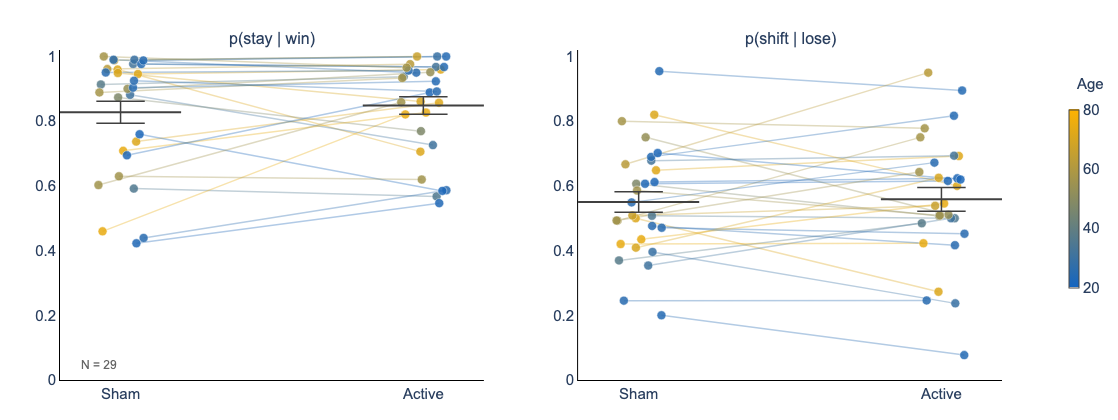

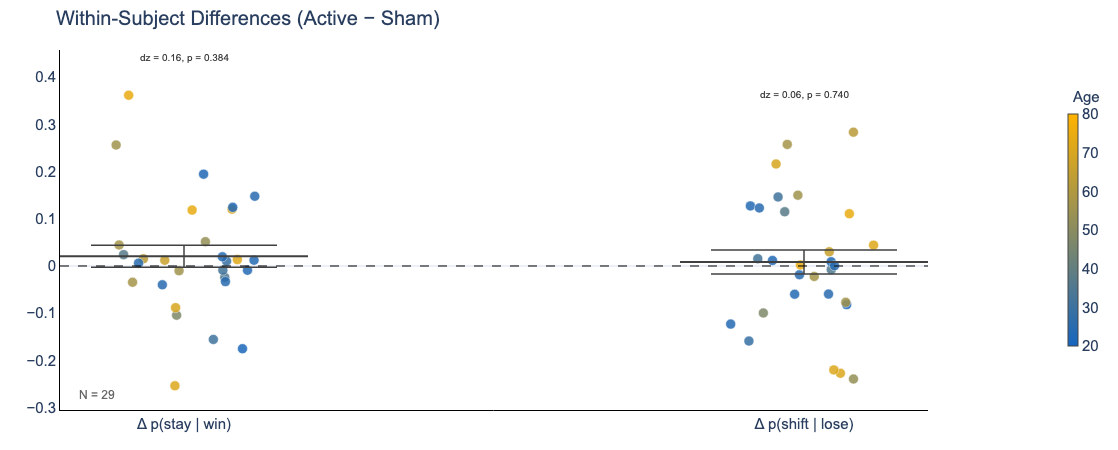

In [12]:
# WSLS analysis for H1 and H2
wsls_results = run_wsls_analysis(data_h1, data_h2, data)

---
## 5. Reversal Learning Analysis

Identified 498 reversals across 31 subjects
Trials in reversal windows: 10363 / 18347

Reversals per subject × condition:
condition   active  baseline  post  sham
subject_id                              
10369            4         4     4     4
10418            4         4     4     4
10541            4         4     4     4
10559            4         4     4     4
10589            4         4     4     4
10606            4         4     4     4
10608            4         4     4     4
10636            4         4     4     4
10638            4         4     4     4
10641            4         4     4     4
10649            4         4     4     4
10656            4         4     4     4
10661            4         4     4     4
10716            4         4     5     4
10809            4         4     4     4
10810            4         4     4     4
10862            4         4     4     4
10866            4         4     4     4
10886            4         4     4     4
10951            

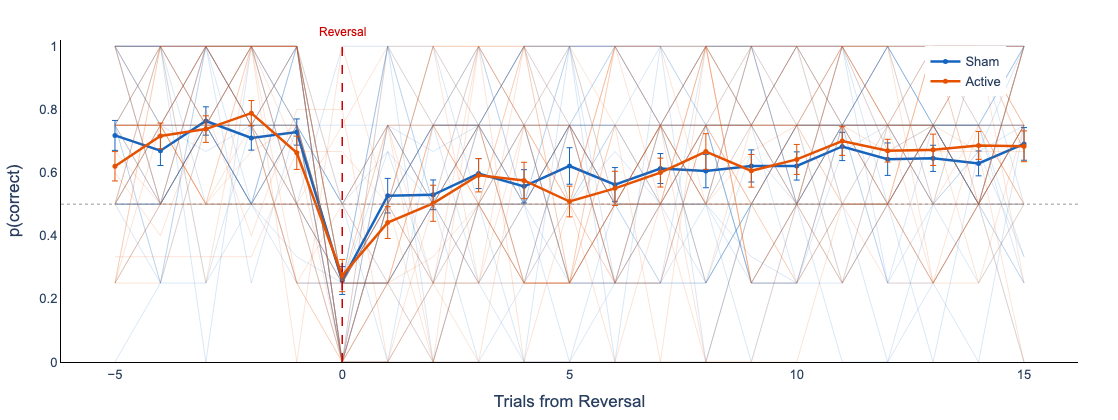

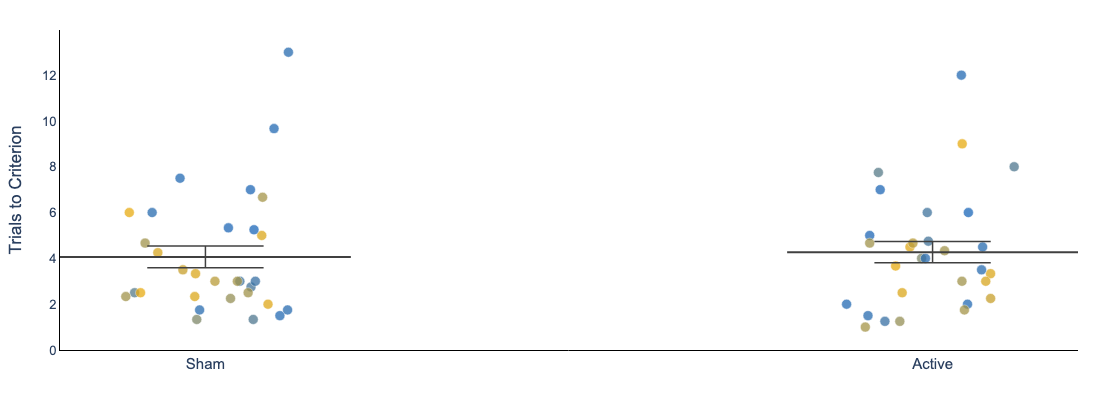

In [20]:
# Reversal-locked accuracy and trials to criterion
rev_results = run_reversal_analysis(data, data_clean, conditions=['sham', 'active'])

---
## 6. Rescorla-Wagner Model

In [ ]:
# Fit R-W model (MLE and MAP)
rw_results = run_rw_analysis(
    data_clean, 
    h2_subjects=h2_eligible,
    run_recovery=False  # Set True to run parameter recovery (slow)
)

---
## 7. Drift Diffusion Model

In [ ]:
# Fit DDM (requires pyddm)
ddm_results = run_ddm_analysis(
    data_clean,
    conditions=['sham', 'active'],
    run_bootstrap=False,  # Set True for bootstrap CI (slow)
    n_bootstrap=200
)

---
## 8. EEG Theta Reactivity

In [ ]:
# Compute theta reactivity from baseline EEG (F4 channel)
# Note: Requires EEG .easy files in DATA_DIR/nic/raw
try:
    theta_results = run_theta_analysis(verbose=True, show_plots=True)
    theta_subject = theta_results.get('theta_subject')
    print(f'\nTheta reliability (ICC): {theta_results["reliability"]["ICC"]:.3f}')
except FileNotFoundError:
    print('EEG files not found - skipping theta analysis')
    theta_results = None
    theta_subject = None

---
## 9. Cognitive & Survey Data Integration

In [ ]:
# Load external data and build subject DataFrame
cog_results = run_cognitive_merge(
    wsls_h1=wsls_results.get('wsls_h1'),
    wsls_h2=wsls_results.get('wsls_h2'),
    rw_mle=rw_results.get('rw_mle'),
    ddm_params=ddm_results.get('ddm_subject') if ddm_results else None,
    theta_subject=theta_subject,
    h2_subjects=h2_eligible
)

subj_df = cog_results['subj_df']
print(f'\nSubject DataFrame: {len(subj_df)} subjects, {len(subj_df.columns)} variables')
if 'theta_p95' in subj_df.columns:
    print(f'Subjects with theta data: {subj_df["theta_p95"].notna().sum()}')

---
## 10. Pre-Registered Hypothesis Tests

In [ ]:
# Run all H1 and H2 tests
hyp_results = run_hypothesis_tests(subj_df, show_plots=True)

---
## 11. Order & Session Effects

In [ ]:
# Check for counterbalance confounds
order_results = run_order_effects_analysis(subj_df)

---
## 12. Correlation Matrix

In [ ]:
# Pairwise correlations among pre-registered variables
# (now includes theta_p95)
corr_results = run_correlation_analysis(subj_df, include_tertiary=False)

---
## 13. Summary

In [ ]:
print('='*70)
print('ANALYSIS SUMMARY')
print('='*70)
print()

# Sample
print(f'Sample: N = {len(subj_df)}')
print(f'  H1-eligible (sham): {data_h1["subject_id"].nunique()}')
print(f'  H2-eligible (paired): {len(h2_eligible)}')
if 'theta_p95' in subj_df.columns:
    print(f'  With theta data: {subj_df["theta_p95"].notna().sum()}')
print()

# Blinding
if blinding_results['blinding_intact']:
    print('✓ Blinding intact')
else:
    print('⚠ Blinding concern')

# Order effects
if order_results['any_significant_order']:
    print('⚠ Significant order × condition interaction')
else:
    print('✓ No significant order effects')

# Theta reliability
if theta_results is not None and 'reliability' in theta_results:
    icc = theta_results['reliability'].get('ICC', np.nan)
    if not np.isnan(icc):
        if icc >= 0.75:
            print(f'✓ Theta reliability excellent (ICC = {icc:.2f})')
        elif icc >= 0.60:
            print(f'✓ Theta reliability good (ICC = {icc:.2f})')
        else:
            print(f'⚠ Theta reliability fair/poor (ICC = {icc:.2f})')
print()

# H2.1 summary
print('H2.1 Paired Comparisons (tACS vs. Sham):')
for param, res in hyp_results['h2_1'].items():
    if res is not None:
        sig = '*' if res['p'] < 0.05 else ''
        print(f"  {param}: dz = {res['dz']:.3f}, p = {res['p']:.3f} {sig}")

---
## Module Reference

| Module | Purpose |
|--------|--------|
| `config.py` | Paths, SUBJECT_INFO, colors, constants |
| `data_loading.py` | Load and preprocess behavioral data |
| `exclusions.py` | Apply behavioral and stim exclusion criteria |
| `sample_descriptives.py` | Demographics, age distribution, cap size |
| `blinding_analysis.py` | Signal detection analysis of blinding |
| `wsls.py` | Win-stay/lose-shift analysis |
| `reversal_analysis.py` | Reversal-locked accuracy curves |
| `rescorla_wagner.py` | R-W model fitting (MLE/MAP) |
| `ddm.py` | Drift diffusion model fitting |
| `eeg_theta.py` | Theta reactivity from baseline EEG |
| `cognitive_merge.py` | External data integration, composites |
| `hypothesis_tests.py` | H1.1, H1.2, H2.1, H2.2, theta moderation |
| `order_effects.py` | Counterbalance and session effects |
| `correlations.py` | Correlation heatmap |
| `plotting_utils.py` | Shared visualization utilities |